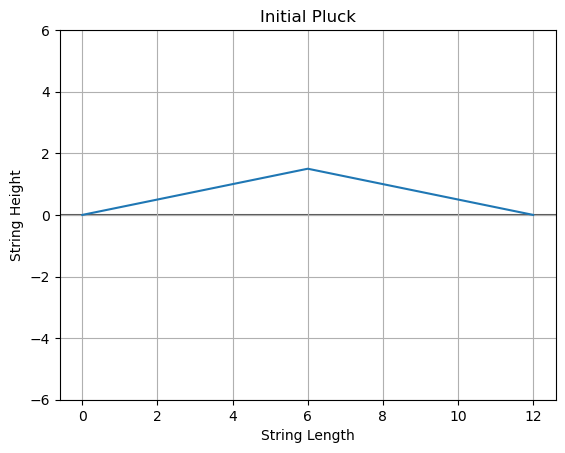

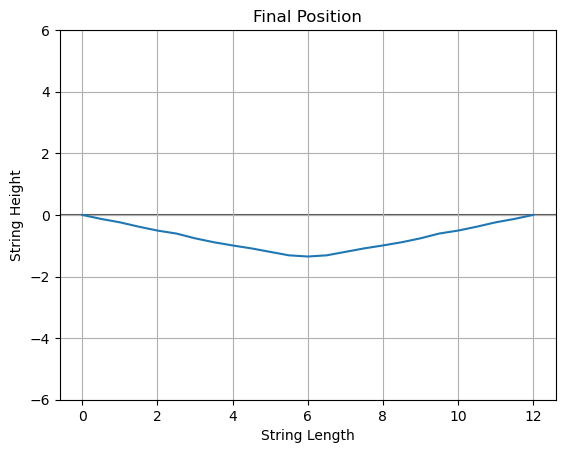

In [117]:
import matplotlib.pyplot as plt
import numpy as np

#Initializing String

displacement = 1.5
length = 12
N = (length*2)+1

x = np.linspace(0,length,N)

mid = max(x)/2
condlist = [x <= mid, x > mid]
funclist = [
    lambda x: displacement*(x/mid), 
    lambda x: displacement*(1-(x-mid)/mid)
]
y = np.piecewise(x,condlist,funclist)

fig, ax = plt.subplots()
ax.plot(x,y,zorder=2)
ax.set_ylim(ymin=-6,ymax=6)
ax.axhline(y=0,color='black',alpha=0.65,zorder=1)

ax.set( 
    xlabel='String Length',
    ylabel='String Height',
    title='Initial Pluck'
)
ax.grid()

#Changing String

v = np.zeros(N)

def stringtimestep(c,dt):
    global y, v
    accel = np.zeros(N)
    for i in range(1,N-1):
        accel[i] = (c**2)*((y[i+1]-2*y[i]+y[i-1])/((x[i]-x[i-1])**2))
    v += accel*dt
    y += v*dt
        
for j in range(0,129):
    stringtimestep(1,0.1)
    j+=1
    
    
fig, ax = plt.subplots()
ax.plot(x,y,zorder=2)
ax.set_ylim(ymin=-6,ymax=6)
ax.axhline(y=0,color='black',alpha=0.65,zorder=1)

ax.set( 
    xlabel='String Length',
    ylabel='String Height',
    title='Final Position'
)
ax.grid()